$$ SYMPY

ODE:
     2                          
    d               d           
1.0⋅───(p(x)) + 9.0⋅──(p(x)) = 0
      2             dx          
    dx                          

General solution:


Eq(p(x), C1 + C2*exp(-9.0*x))


Constants:


{C1: 1.00012342503595, C2: -1.00012342503595}


Final solution:


1.00012342503595 - 1.00012342503595*exp(-9.0*x)

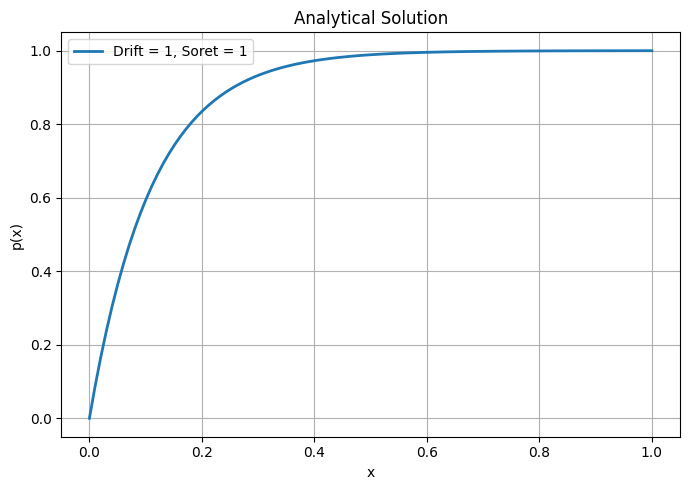

In [95]:
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np

x = sp.symbols('x')
p = sp.Function('p')(x)

D, V, S = sp.symbols('D V S', positive=True)
D, V, S = 1.0, 1.0, 1.0

drift_flag = 1
soret_flag = 1

T = 300 + 10*x

diffusion_term = D * sp.diff(p, x, 2)
drift_term = - V * sp.diff(p, x)
soret_term = D * S * sp.diff(p * sp.diff(T, x), x)

ode = sp.Eq(diffusion_term + drift_flag * drift_term + soret_flag * soret_term, 0)
print("ODE:")
sp.pprint(ode, order='none')

general_solution = sp.dsolve(ode)
print("\nGeneral solution:")
display(general_solution)

solution = general_solution.rhs

C1, C2 = sp.symbols('C1 C2')
bc1 = sp.Eq(solution.subs(x,0), 0)
bc2 = sp.Eq(solution.subs(x,1), 1)
constants = sp.solve([bc1, bc2], [C1, C2])

final_solution = sp.simplify(solution.subs(constants))

print("\nConstants:")
display(constants)

print("\nFinal solution:")
display(final_solution)

x_values = np.linspace(0, 1, 100)
p_function = sp.lambdify(x, final_solution, 'numpy')
p_values = p_function(x_values)

plt.figure(figsize=(7, 5))
plt.plot(x_values, p_values, linewidth=2, label=f"Drift = {drift_flag}, Soret = {soret_flag}")
plt.xlabel("x")
plt.ylabel("p(x)")
plt.title("Analytical Solution")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


$$ FIPY

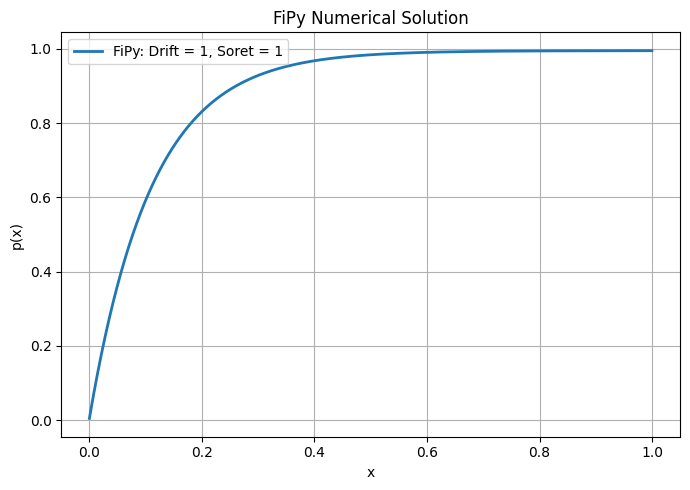

In [96]:
from fipy import CellVariable, FaceVariable, Grid1D, DiffusionTerm, PowerLawConvectionTerm
import numpy as np
import matplotlib.pyplot as plt

L = 1.0
nx = 1000
dx = L / nx

mesh = Grid1D(nx=nx, dx=dx)
x_s = mesh.cellCenters[0]

T_f = CellVariable(name="Temperature", mesh=mesh, value=300.0 + 10.0 * x_s)
p_f = CellVariable(name ="Carrier Concentration", mesh=mesh, value=0.0)

p_f.constrain(0.0, mesh.facesLeft)
p_f.constrain(1.0, mesh.facesRight)

V_f = FaceVariable(mesh=mesh, rank=1, value=1.0,)

equation = (DiffusionTerm(coeff=D) == drift_flag * PowerLawConvectionTerm(coeff=V_f) - soret_flag * PowerLawConvectionTerm(coeff=D * S * T_f.faceGrad))
equation.solve(var=p_f)

x_values = x_s.value

plt.figure(figsize=(7,5))
plt.plot(x_values, p_f, linewidth=2, label=f"FiPy: Drift = {drift_flag}, Soret = {soret_flag}")
plt.xlabel("x")
plt.ylabel("p(x)")
plt.title("FiPy Numerical Solution")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

$$COMPARISON

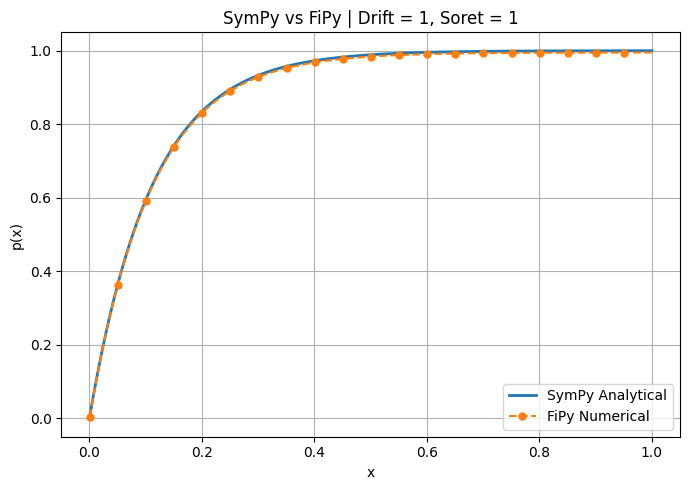

In [97]:
x_sympy = np.linspace(0, 1, 500)
p_sympy_function = sp.lambdify(x, final_solution, 'numpy')
p_sympy = p_sympy_function(x_sympy)

x_fipy = x_s.value
p_fipy = p_f.value

plt.figure(figsize=(7,5))
plt.plot(x_sympy, p_sympy, '-', linewidth=2, label='SymPy Analytical')
plt.plot(x_fipy, p_fipy, '--', marker='o', markersize=5, markevery=50, linewidth=1.5, label='FiPy Numerical')
plt.ylabel("p(x)")
plt.xlabel("x")
plt.title(f"SymPy vs FiPy | Drift = {drift_flag}, Soret = {soret_flag}")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()